In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib,pyplot as plt
from sklearn.cross_decomposition import PLSregresssion
from sklearn.metrics import mean_absolute_error

pure_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

alphas = np.arrange(0.1,0.5,0.1)
n_components = 5
true_y = 0.2

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:,1].values

def normalize(x):
    return x/ np.linalg.norm(x)

def average_replicates 


Loaded CF3 pure spectra (7468 features)
Loaded 4 solvent spectra
Synthetic calibration size: 2904
YH_2025_009_DEE_A.CSV: y = 0.8988, MAE = 0.0988
YH_2025_009_DEE_B.CSV: y = 0.9042, MAE = 0.1042
YH_2025_009_DEE_C.CSV: y = 0.9456, MAE = 0.1456
YH_2025_009_DMSO_A.CSV: y = 0.8543, MAE = 0.0543
YH_2025_009_DMSO_B.CSV: y = 0.8611, MAE = 0.0611
YH_2025_009_DMSO_C.CSV: y = 0.8361, MAE = 0.0361
YH_2025_009_IPA_A.CSV: y = 0.9098, MAE = 0.1098
YH_2025_009_IPA_B.CSV: y = 0.8638, MAE = 0.0638
YH_2025_009_IPA_C.CSV: y = 0.8989, MAE = 0.0989
YH_2025_009_Water_A.CSV: y = 0.8241, MAE = 0.0241
YH_2025_009_Water_B.CSV: y = 0.8231, MAE = 0.0231
YH_2025_009_Water_C.CSV: y = 0.9853, MAE = 0.1853

Average MAE: 0.0838


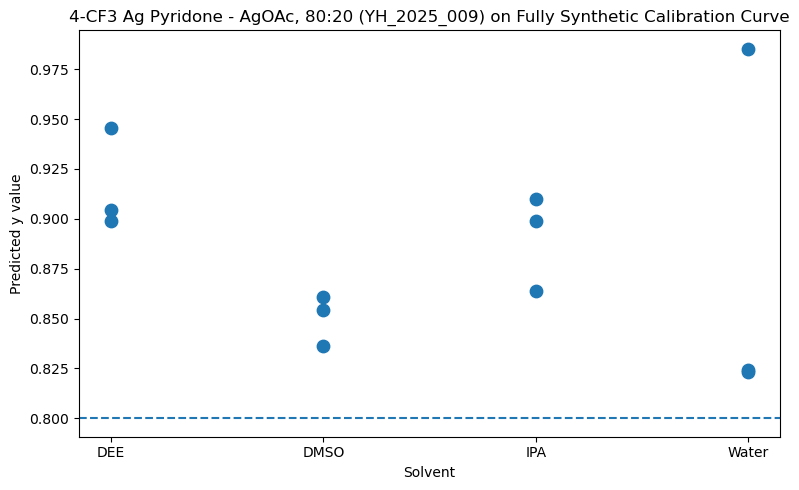


Results saved to YH_2025_009_AgOAc_solvent_anchored_pls.csv


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

fractions     = np.linspace(0.4, 1.2, 121)   
alphas        = np.linspace(0.06, 0.28, 6)   
n_components  = 5               
true_y        = 0.8               

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def average_replicates(files):
    specs = [load_spectrum(f) for f in files]
    min_len = min(len(s) for s in specs)
    specs = [s[:min_len] for s in specs]
    return np.mean(specs, axis=0)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )
    s = normalize(s)
    s = savgol(s)
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:
            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)
            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Fully Synthetic Calibration Curve')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})

Synthetic calibration set size: 1936 samples × 7468 features
YH_2025_009_DEE_A.CSV: y = 0.8150, MAE = 0.0150
YH_2025_009_DEE_B.CSV: y = 0.8128, MAE = 0.0128
YH_2025_009_DEE_C.CSV: y = 0.8146, MAE = 0.0146
YH_2025_009_DMSO_A.CSV: y = 0.8141, MAE = 0.0141
YH_2025_009_DMSO_B.CSV: y = 0.8142, MAE = 0.0142
YH_2025_009_DMSO_C.CSV: y = 0.8123, MAE = 0.0123
YH_2025_009_IPA_A.CSV: y = 0.8145, MAE = 0.0145
YH_2025_009_IPA_B.CSV: y = 0.8142, MAE = 0.0142
YH_2025_009_IPA_C.CSV: y = 0.8142, MAE = 0.0142
YH_2025_009_Water_A.CSV: y = 0.8120, MAE = 0.0120
YH_2025_009_Water_B.CSV: y = 0.8119, MAE = 0.0119
YH_2025_009_Water_C.CSV: y = 0.8120, MAE = 0.0120

Average MAE: 0.0135


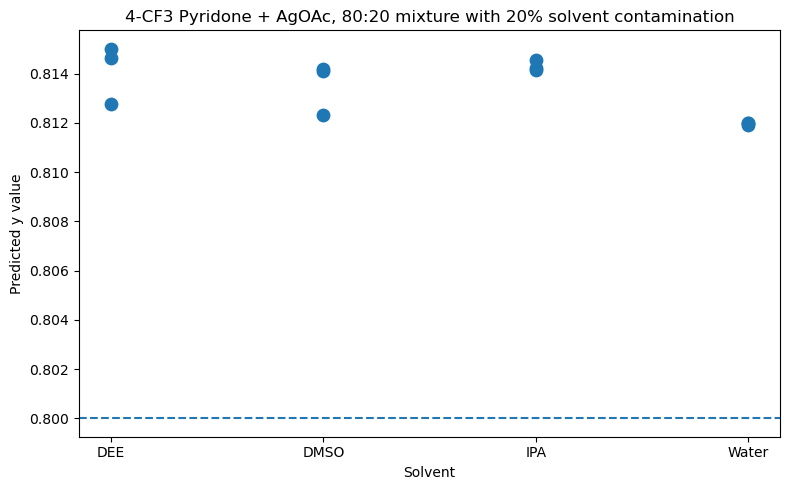

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # 4-CF3 + AgOAc
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

# SETTINGS
fractions      = np.linspace(0.0, 1.2, 121)  # full calibration curve
alphas = np.arange(0.05, 0.25, 0.05)  # up to 20%                     # 20% solvent contamination
n_components   = 5
true_fraction_alpha = 0.8                      # test mixture fraction Alpha
true_fraction_ag    = 0.2                      # test mixture fraction AgOAc

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol_filter_spec(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def synthesize_spectrum(alpha_spec, ag_spec, fraction_alpha):
    return fraction_alpha * alpha_spec + (1 - fraction_alpha) * ag_spec

# LOAD PURE
alpha_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

ag_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in alpha_files]
ag_specs    = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in ag_files]

#LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = np.interp(np.linspace(0, 1, len(alpha_specs[0])), np.linspace(0, 1, len(s)), s)
    s = normalize(savgol_filter_spec(s))
    solvents.append(s)

# SYNTHETIC CALIBRATION
X_cal, y_cal = [], []

rng = np.random.default_rng(42)
for solvent in solvents:
    for frac in fractions:
        for alpha_val in alphas:
            # randomly pick alpha and AgOAc spectra
            alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
            ag_spec    = ag_specs[rng.integers(len(ag_specs))]

            # make mixture + solvent contamination
            mix_spec = synthesize_spectrum(alpha_spec, ag_spec, frac)
            synthetic_spec = (mix_spec + alpha_val * solvent) / (1 + alpha_val)

            X_cal.append(synthetic_spec)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
print(f"Synthetic calibration set size: {X_cal.shape[0]} samples × {X_cal.shape[1]} features")

# SCALE & MODEL
scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# TEST
test_files = sorted(f for f in os.listdir(test_dir) if f.lower().endswith('.csv'))

predictions, maes = [], []

for f in test_files:
    # choose random alpha and AgOAc for the test mixture
    alpha_spec = alpha_specs[rng.integers(len(alpha_specs))]
    ag_spec    = ag_specs[rng.integers(len(ag_specs))]

    # make 80:20 mixture
    s_test = synthesize_spectrum(alpha_spec, ag_spec, true_fraction_alpha)

    # add 20% solvent contamination (choose corresponding solvent from file name)
    solvent_idx = None
    for i, sol in enumerate(['DEE','DMSO','IPA','Water']):
        if sol in f:
            solvent_idx = i
            break
    if solvent_idx is not None:
        s_test = (s_test + alphas[0] * solvents[solvent_idx]) / (1 + alphas[0])

    s_scaled = scaler.transform(s_test.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])
    mae = mean_absolute_error([true_fraction_alpha], [y_pred])

    predictions.append((f, y_pred))
    maes.append(mae)
    print(f"{f}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

# PLOT
labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_fraction_alpha, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Pyridone + AgOAc, 80:20 mixture with 20% solvent contamination')
plt.tight_layout()
plt.show()

In [2]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

# SETTINGS
fractions = np.linspace(0.0, 1.2, 121)
alphas    = np.arange(0.05, 0.25, 0.05)   # 20% contamination range
n_components = 5
n_splits = 5

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol_filter_spec(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)

def synthesize_spectrum(alpha_spec, ag_spec, fraction_alpha):
    return fraction_alpha * alpha_spec + (1 - fraction_alpha) * ag_spec

# LOAD PURE SPECTRA
alpha_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

ag_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in alpha_files]
ag_specs    = [normalize(savgol_filter_spec(load_spectrum(os.path.join(pure_dir, f)))) for f in ag_files]

n_features = min(len(s) for s in alpha_specs)
alpha_specs = [s[:n_features] for s in alpha_specs]
ag_specs    = [s[:n_features] for s in ag_specs]

print(f"Loaded Alpha + AgOAc spectra ({n_features} features)")

# LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    s = np.interp(np.linspace(0,1,n_features), np.linspace(0,1,len(s)), s)
    s = normalize(savgol_filter_spec(s))
    solvents.append(s)

print(f"Loaded {len(solvents)} solvent spectra")

# SYNTHETIC DATA + GROUPS
X_cal, y_cal, groups = [], [], []

rng = np.random.default_rng(42)
group_id = 0

for solvent_idx, solvent in enumerate(solvents):
    for i_alpha, alpha_base in enumerate(alpha_specs):
        for i_ag, ag_base in enumerate(ag_specs):

            # ONE group = same base spectra + solvent
            for frac in fractions:
                for alpha_val in alphas:

                    mix_spec = synthesize_spectrum(alpha_base, ag_base, frac)
                    synthetic = (mix_spec + alpha_val * solvent) / (1 + alpha_val)

                    X_cal.append(synthetic)
                    y_cal.append(frac)
                    groups.append(group_id)

            group_id += 1  # increment AFTER full family

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
groups = np.array(groups)

print(f"Synthetic dataset: {X_cal.shape[0]} samples")
print(f"Total groups: {len(np.unique(groups))}")

#  GROUP K-FOLD CV 
gkf = GroupKFold(n_splits=n_splits)

mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cal, y_cal, groups)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X_cal[train_idx], X_cal[test_idx]
    y_train, y_test = y_cal[train_idx], y_cal[test_idx]

    # IMPORTANT: fit scaler ONLY on training data
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train_scaled, y_train)

    y_pred = pls.predict(X_test_scaled).ravel()
    mae = mean_absolute_error(y_test, y_pred)

    mae_scores.append(mae)
    print(f"MAE: {mae:.4f}")

print("\n========================")
print(f"CV MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print("========================")

Loaded Alpha + AgOAc spectra (7468 features)
Loaded 4 solvent spectra
Synthetic dataset: 17424 samples
Total groups: 36

Fold 1
MAE: 0.0134

Fold 2
MAE: 0.0134

Fold 3
MAE: 0.0134

Fold 4
MAE: 0.0134

Fold 5
MAE: 0.0134

CV MAE: 0.0134 ± 0.0000


Loaded CF3 pure spectra (7468 features)
Loaded 4 solvent spectra
Synthetic calibration size: 2904
YH_2025_012_DEE_A.CSV: y = 0.7638, MAE = 0.0362
YH_2025_012_DEE_B.CSV: y = 0.7662, MAE = 0.0338
YH_2025_012_DEE_C.CSV: y = 0.7678, MAE = 0.0322
YH_2025_012_DMSO_A.CSV: y = 0.7634, MAE = 0.0366
YH_2025_012_DMSO_B.CSV: y = 0.7589, MAE = 0.0411
YH_2025_012_DMSO_C.CSV: y = 0.7706, MAE = 0.0294
YH_2025_012_IPA_A(real).CSV: y = 0.7789, MAE = 0.0211
YH_2025_012_IPA_B(real).CSV: y = 0.7675, MAE = 0.0325
YH_2025_012_IPA_C(real).CSV: y = 0.7578, MAE = 0.0422
YH_2025_012_Water_A.CSV: y = 0.7317, MAE = 0.0683
YH_2025_012_Water_B.CSV: y = 0.7250, MAE = 0.0750
YH_2025_012_Water_C.CSV: y = 0.7439, MAE = 0.0561

Average MAE: 0.0420


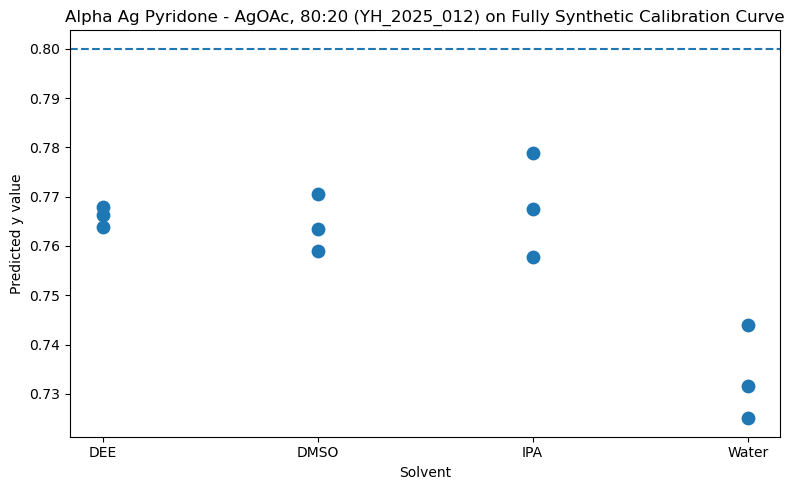

In [17]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

fractions     = np.linspace(0.4, 1.2, 121)   
alphas        = np.linspace(0.06, 0.28, 6)   
n_components  = 5               
true_y        = 0.8               

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def average_replicates(files):
    specs = [load_spectrum(f) for f in files]
    min_len = min(len(s) for s in specs)
    specs = [s[:min_len] for s in specs]
    return np.mean(specs, axis=0)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_ALPHA_A.CSV',
    'YH_2025_010_ALPHA_B.CSV',
    'YH_2025_010_ALPHA_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )
    s = normalize(s)
    s = savgol(s)
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:
            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)
            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('Alpha Ag Pyridone - AgOAc, 80:20 (YH_2025_012) on Fully Synthetic Calibration Curve')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})

Synthetic calibration set size: 3213 samples × 7468 features
YH_2025_012_DEE_A.CSV: y=0.8261, MAE=0.0261
YH_2025_012_DEE_B.CSV: y=0.9001, MAE=0.1001
YH_2025_012_DEE_C.CSV: y=0.8261, MAE=0.0261
YH_2025_012_DMSO_A.CSV: y=0.8796, MAE=0.0796
YH_2025_012_DMSO_B.CSV: y=0.8261, MAE=0.0261
YH_2025_012_DMSO_C.CSV: y=0.8796, MAE=0.0796
YH_2025_012_IPA_A(real).CSV: y=0.8871, MAE=0.0871
YH_2025_012_IPA_B(real).CSV: y=0.8796, MAE=0.0796
YH_2025_012_IPA_C(real).CSV: y=0.8992, MAE=0.0992
YH_2025_012_Water_A.CSV: y=0.8261, MAE=0.0261
YH_2025_012_Water_B.CSV: y=0.8261, MAE=0.0261
YH_2025_012_Water_C.CSV: y=0.8871, MAE=0.0871

Average MAE: 0.0619


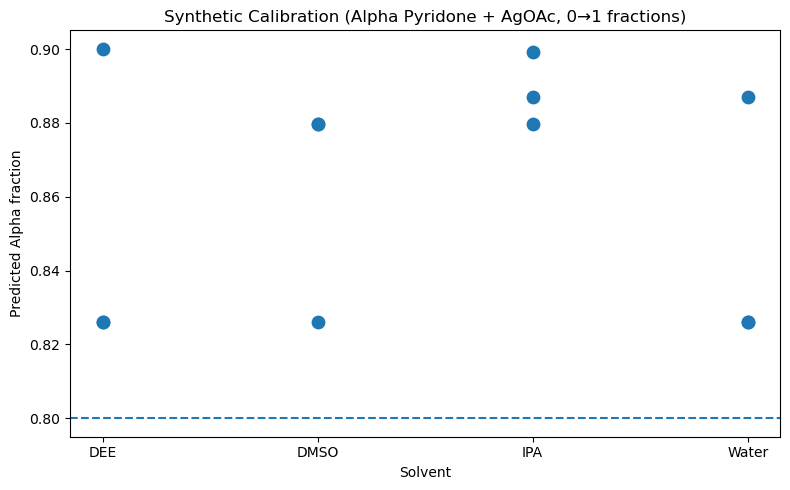

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# PATHS
alpha_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # Alpha Pyridone spectra (triplicates)
agoac_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'  # AgOAc spectra (triplicates)
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir  = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_012/'

#SETTINGS
n_components = 5
true_fraction_alpha = 0.8  # test mixture 80:20
alpha_solvent_values = np.arange(0.1, 0.5, 0.1)  # 10-40% solvent contamination

# FILES
alpha_files = ['YH_2025_010_ALPHA_A.CSV',
               'YH_2025_010_ALPHA_B.CSV',
               'YH_2025_010_ALPHA_C.CSV']

agoac_files = ['YH_2025_010_AgOAC_A.CSV',
               'YH_2025_010_AgOAC_B.CSV',
               'YH_2025_010_AgOAC_C.CSV']

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:,1].values

def synthesize_spectrum(alpha_s, ag_s, fraction):
    """Linear combination of Alpha Pyridone and AgOAc"""
    return fraction * alpha_s + (1 - fraction) * ag_s

#LOAD PURE SPECTRA 
alpha_specs = np.array([load_spectrum(os.path.join(alpha_dir,f)) for f in alpha_files])
agoac_specs = np.array([load_spectrum(os.path.join(agoac_dir,f)) for f in agoac_files])

n_features = min(alpha_specs.shape[1], agoac_specs.shape[1])
alpha_specs = alpha_specs[:, :n_features]
agoac_specs = agoac_specs[:, :n_features]

# LOAD SOLVENTS
solvents = {}
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir,f))[:n_features]
    solvents[f.split('.')[0]] = s

#SYNTHETIC CALIBRATION
fractions = np.linspace(0,1,21)  # full calibration
X_cal, y_cal = [], []

for alpha_s in alpha_specs:
    for ag_s in agoac_specs:
        for frac in fractions:
            base_spectrum = synthesize_spectrum(alpha_s, ag_s, frac)
            X_cal.append(base_spectrum)
            y_cal.append(frac)

# Add solvent contamination to calibration
X_aug, y_aug = [], []
for spec, y_val in zip(X_cal, y_cal):
    X_aug.append(spec)
    y_aug.append(y_val)
    for solvent_name, solvent_spec in solvents.items():
        for alpha_sol in alpha_solvent_values:
            contaminated = (spec + alpha_sol * solvent_spec)/(1+alpha_sol)
            X_aug.append(contaminated)
            y_aug.append(y_val)

X_cal = np.array(X_aug)
y_cal = np.array(y_aug)
print(f"Synthetic calibration set size: {X_cal.shape[0]} samples × {X_cal.shape[1]} features")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

# MODEL
pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

# TEST
test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])

predictions, maes = [], []

for f in test_files:
    # Choose random alpha and AgOAc spectra for the test mixture
    s_alpha = alpha_specs[np.random.randint(len(alpha_specs))]
    s_ag    = agoac_specs[np.random.randint(len(agoac_specs))]

    # Make 80:20 mixture for testing
    s_test = synthesize_spectrum(s_alpha, s_ag, true_fraction_alpha)

    s_scaled = scaler.transform(s_test.reshape(1,-1))
    y_pred = float(pls.predict(s_scaled)[0])
    mae = mean_absolute_error([true_fraction_alpha],[y_pred])

    predictions.append((f, y_pred))
    maes.append(mae)

    print(f"{f}: y={y_pred:.4f}, MAE={mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

#pLOT
solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions, y_plot = [], []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_fraction_alpha, linestyle='--')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted Alpha fraction')
plt.title('Synthetic Calibration (Alpha Pyridone + AgOAc, 0→1 fractions)')
plt.tight_layout()
plt.show()

In [3]:
import os
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold

#PATHS
alpha_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
agoac_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'

#SETTINGS
n_components = 5
alpha_solvent_values = np.arange(0.1, 0.5, 0.1)
fractions = np.linspace(0,1,21)
n_splits = 5

# FUNCTIONS
def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:,1].values

def synthesize_spectrum(alpha_s, ag_s, fraction):
    return fraction * alpha_s + (1 - fraction) * ag_s

# LOAD PURE 
alpha_files = [
    'YH_2025_010_ALPHA_A.CSV',
    'YH_2025_010_ALPHA_B.CSV',
    'YH_2025_010_ALPHA_C.CSV'
]

agoac_files = [
    'YH_2025_010_AgOAC_A.CSV',
    'YH_2025_010_AgOAC_B.CSV',
    'YH_2025_010_AgOAC_C.CSV'
]

alpha_specs = np.array([load_spectrum(os.path.join(alpha_dir,f)) for f in alpha_files])
agoac_specs = np.array([load_spectrum(os.path.join(agoac_dir,f)) for f in agoac_files])

n_features = min(alpha_specs.shape[1], agoac_specs.shape[1])
alpha_specs = alpha_specs[:, :n_features]
agoac_specs = agoac_specs[:, :n_features]

# LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = []
for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir,f))[:n_features]
    solvents.append(s)

# SYNTHETIC + GROUPS
X_cal, y_cal, groups = [], [], []

group_id = 0

for i_alpha, alpha_s in enumerate(alpha_specs):
    for i_ag, ag_s in enumerate(agoac_specs):
        for frac in fractions:

            base_spec = synthesize_spectrum(alpha_s, ag_s, frac)

            # group = same base spectrum
            # (all solvent augmentations belong here)

            # original (no solvent)
            X_cal.append(base_spec)
            y_cal.append(frac)
            groups.append(group_id)

            # solvent augmented
            for solvent in solvents:
                for alpha_sol in alpha_solvent_values:
                    contaminated = (base_spec + alpha_sol * solvent)/(1+alpha_sol)

                    X_cal.append(contaminated)
                    y_cal.append(frac)
                    groups.append(group_id)

            group_id += 1

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)
groups = np.array(groups)

print(f"Synthetic dataset: {X_cal.shape[0]} samples")
print(f"Total groups: {len(np.unique(groups))}")

#  GROUP K-FOLD
gkf = GroupKFold(n_splits=n_splits)

mae_scores = []

for fold, (train_idx, test_idx) in enumerate(gkf.split(X_cal, y_cal, groups)):
    print(f"\nFold {fold+1}")

    X_train, X_test = X_cal[train_idx], X_cal[test_idx]
    y_train, y_test = y_cal[train_idx], y_cal[test_idx]

    # scale properly (no leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    pls = PLSRegression(n_components=n_components)
    pls.fit(X_train_scaled, y_train)

    y_pred = pls.predict(X_test_scaled).ravel()
    mae = mean_absolute_error(y_test, y_pred)

    mae_scores.append(mae)
    print(f"MAE: {mae:.4f}")

print("\n========================")
print(f"CV MAE: {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print("========================")

Synthetic dataset: 3213 samples
Total groups: 189

Fold 1
MAE: 0.0364

Fold 2
MAE: 0.0354

Fold 3
MAE: 0.0355

Fold 4
MAE: 0.0361

Fold 5
MAE: 0.0335

CV MAE: 0.0354 ± 0.0010


Loaded CF3 pure spectra (7468 features)
Loaded 9 solvent spectra (HFIP/DCE/Toluene, A–C)
Synthetic calibration size: 6534
YH_2025_009_DEE_A.CSV: y = 0.8213, MAE = 0.0213
YH_2025_009_DEE_B.CSV: y = 0.8207, MAE = 0.0207
YH_2025_009_DEE_C.CSV: y = 0.8332, MAE = 0.0332
YH_2025_009_DMSO_A.CSV: y = 0.8122, MAE = 0.0122
YH_2025_009_DMSO_B.CSV: y = 0.8120, MAE = 0.0120
YH_2025_009_DMSO_C.CSV: y = 0.8074, MAE = 0.0074
YH_2025_009_IPA_A.CSV: y = 0.8221, MAE = 0.0221
YH_2025_009_IPA_B.CSV: y = 0.8065, MAE = 0.0065
YH_2025_009_IPA_C.CSV: y = 0.8141, MAE = 0.0141
YH_2025_009_Water_A.CSV: y = 0.8009, MAE = 0.0009
YH_2025_009_Water_B.CSV: y = 0.8043, MAE = 0.0043
YH_2025_009_Water_C.CSV: y = 0.8611, MAE = 0.0611

Average MAE: 0.0180


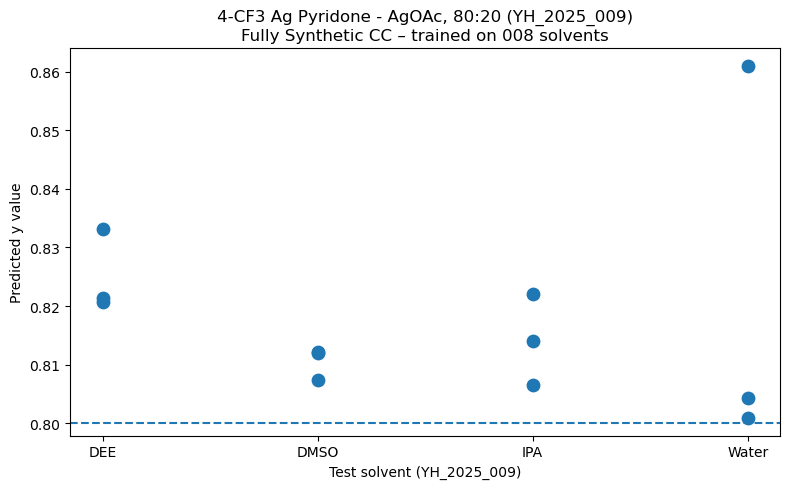

In [5]:
#Optimization Testing
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

fractions     = np.linspace(0.4, 1.2, 121)
alphas        = np.linspace(0.06, 0.28, 6)
n_components  = 5
true_y        = 0.8

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")


solvent_files = [
    'YH_2025_008_HFIP_A.csv',
    'YH_2025_008_HFIP_B.csv',
    'YH_2025_008_HFIP_C.csv',

    'YH_2025_008_DCE_A.csv',
    'YH_2025_008_DCE_B.csv',
    'YH_2025_008_DCE_C.csv',

    'YH_2025_008_Toluene_A.csv',
    'YH_2025_008_Toluene_B.csv',
    'YH_2025_008_Toluene_C.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))

    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )

    s = normalize(s)
    s = savgol(s)

    solvents.append(s)

solvents = np.array(solvents)

print(f"Loaded {len(solvents)} solvent spectra (HFIP/DCE/Toluene, A–C)")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:

            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)

            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")


scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)


test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:

    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = []
y = []

for fname, ypred in predictions:
    # YH_2025_009_DEE_A.CSV  ->  DEE
    solvent = fname.split('_')[3]
    labels.append(solvent)
    y.append(ypred)

unique_labels = list(dict.fromkeys(labels))
x_map = {s: i for i, s in enumerate(unique_labels)}
x = [x_map[s] for s in labels]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(unique_labels)), unique_labels)
plt.xlabel('Test solvent (YH_2025_009)')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009)\nFully Synthetic CC – trained on 008 solvents')
plt.tight_layout()
plt.show()

Loaded CF3 pure spectra (7468 features)
Loaded 9 solvent spectra
Synthetic calibration size: 6534
YH_2025_009_DEE_A.CSV: y = 0.8213, MAE = 0.0213
YH_2025_009_DEE_B.CSV: y = 0.8207, MAE = 0.0207
YH_2025_009_DEE_C.CSV: y = 0.8332, MAE = 0.0332
YH_2025_009_DMSO_A.CSV: y = 0.8122, MAE = 0.0122
YH_2025_009_DMSO_B.CSV: y = 0.8120, MAE = 0.0120
YH_2025_009_DMSO_C.CSV: y = 0.8074, MAE = 0.0074
YH_2025_009_IPA_A.CSV: y = 0.8221, MAE = 0.0221
YH_2025_009_IPA_B.CSV: y = 0.8065, MAE = 0.0065
YH_2025_009_IPA_C.CSV: y = 0.8141, MAE = 0.0141
YH_2025_009_Water_A.CSV: y = 0.8009, MAE = 0.0009
YH_2025_009_Water_B.CSV: y = 0.8043, MAE = 0.0043
YH_2025_009_Water_C.CSV: y = 0.8611, MAE = 0.0611

Average MAE: 0.0180


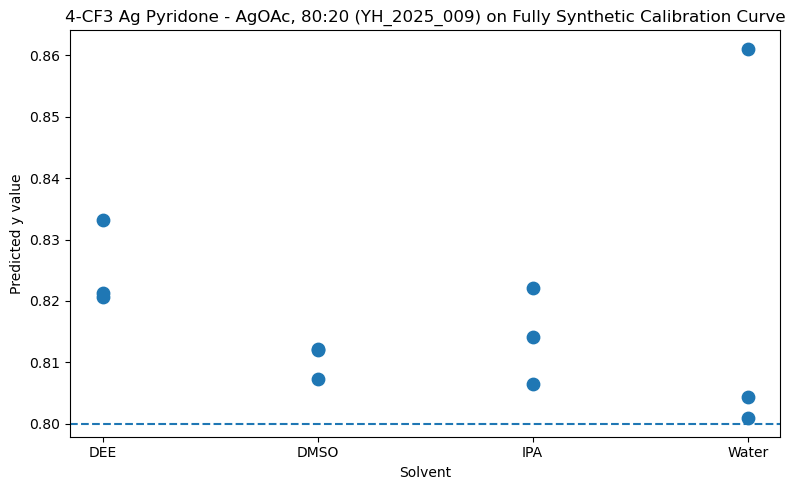

In [1]:
#Optimization Testing
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy.signal import savgol_filter

pure_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_010/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

fractions     = np.linspace(0.4, 1.2, 121)   
alphas        = np.linspace(0.06, 0.28, 6)   
n_components  = 5            
true_y        = 0.8               

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def normalize(x):
    return x / np.linalg.norm(x)

def average_replicates(files):
    specs = [load_spectrum(f) for f in files]
    min_len = min(len(s) for s in specs)
    specs = [s[:min_len] for s in specs]
    return np.mean(specs, axis=0)

def savgol(x):
    return savgol_filter(x, window_length=15, polyorder=3, deriv=2)


cf3_files = [
    'YH_2025_010_4CF3_A.CSV',
    'YH_2025_010_4CF3_B.CSV',
    'YH_2025_010_4CF3_C.CSV'
]

pure_cf3 = np.array([
    load_spectrum(os.path.join(pure_dir, f))
    for f in cf3_files
])

n_features = min(len(s) for s in pure_cf3)
pure_cf3 = pure_cf3[:, :n_features]
pure_cf3 = np.array([normalize(s) for s in pure_cf3])
pure_cf3 = np.array([savgol(s) for s in pure_cf3])

pure_mean = pure_cf3.mean(axis=0)

print(f"Loaded CF3 pure spectra ({n_features} features)")

solvent_files = [
    'YH_2025_008_HFIP_A.csv',
    'YH_2025_008_HFIP_B.csv',
    'YH_2025_008_HFIP_C.csv',

    'YH_2025_008_DCE_A.csv',
    'YH_2025_008_DCE_B.csv',
    'YH_2025_008_DCE_C.csv',

    'YH_2025_008_Toluene_A.csv',
    'YH_2025_008_Toluene_B.csv',
    'YH_2025_008_Toluene_C.csv'
]

solvents = []

for f in solvent_files:
    s = load_spectrum(os.path.join(solvent_dir, f))
    if len(s) != n_features:
        s = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(s)),
            s
        )
    s = normalize(s)
    s = savgol(s)
    solvents.append(s)

solvents = np.array(solvents)
print(f"Loaded {len(solvents)} solvent spectra")

X_cal, y_cal = [], []

rng = np.random.default_rng(42)

for solvent in solvents:
    for frac in fractions:
        for alpha in alphas:
            ref = pure_cf3[rng.integers(len(pure_cf3))]
            delta = frac * (ref - pure_mean)
            synthetic = solvent + alpha * delta

            X_cal.append(synthetic)
            y_cal.append(frac)

X_cal = np.array(X_cal)
y_cal = np.array(y_cal)

print(f"Synthetic calibration size: {len(X_cal)}")

scaler = StandardScaler()
X_cal_scaled = scaler.fit_transform(X_cal)

pls = PLSRegression(n_components=n_components)
pls.fit(X_cal_scaled, y_cal)

test_files = sorted(
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
)

predictions, maes = [], []

for file in test_files:
    s = load_spectrum(os.path.join(test_dir, file))[:n_features]
    s = normalize(s)
    s = savgol(s)

    s_scaled = scaler.transform(s.reshape(1, -1))
    y_pred = float(pls.predict(s_scaled)[0])

    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((file, y_pred))
    maes.append(mae)

    print(f"{file}: y = {y_pred:.4f}, MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = ['DEE', 'DMSO', 'IPA', 'Water']
x = np.repeat(np.arange(len(labels)), 3)
y = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, s=80)
plt.axhline(true_y, linestyle='--')
plt.xticks(range(len(labels)), labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Fully Synthetic Calibration Curve')
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})